In [1]:
!pip install scikit-learn


**Import libraries**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [3]:
df = pd.read_csv("C:\\Users\\RAVI\\Downloads\\improved_api_bot_detection_10000.csv")

**Basic Checks**

In [4]:
df.head(30)

,ip_address,timestamp,http_method,endpoint,status_code,response_size,user_agent,device_type,browser,operating_system,...,url_length,query_param_count,payload_size,is_proxy,is_datacenter_ip,distinct_endpoints_accessed,login_attempts,rate_limit_triggered,request_pattern_entropy,is_bot
0,7.190.71.63,2025-01-11 20:03:33,POST,/api/cart,401,4664,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Desktop,Opera,iOS,...,41,3,7359,0,0,5,1,0,2.89,0
1,2.195.207.41,2025-01-21 12:22:53,PUT,/api/products,500,4592,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Mobile,Safari,Windows,...,22,6,1291,0,0,1,2,0,2.36,0
2,159.227.221.93,2025-01-29 00:39:50,POST,/api/cart,400,3232,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Desktop,Firefox,Linux,...,37,3,4374,0,0,3,0,0,2.22,0
3,19.156.163.44,2025-01-26 22:19:05,POST,/api/search,429,2393,Mozilla/5.0 (iPhone; CPU iPhone OS 17_1 like M...,Server,Safari,Android,...,19,3,9292,0,1,3,0,0,2.22,0
4,168.128.102.227,2025-01-23 06:36:04,POST,/api/products,400,4374,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Mobile,Opera,Android,...,46,1,771,0,0,2,3,0,1.47,0
5,41.203.175.109,2025-01-29 22:52:00,GET,/api/orders,404,1113,Mozilla/5.0 (compatible; SemrushBot/7~bl; +htt...,Server,Opera,Linux,...,33,6,2591,1,0,9,13,0,0.63,1
6,225.185.68.249,2025-01-25 07:13:30,POST,/api/user/profile,200,2855,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Tablet,Opera,Android,...,46,0,1832,0,0,5,1,0,1.22,0
7,213.207.79.62,2025-01-03 19:29:15,POST,/api/user/profile,403,4522,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Desktop,Edge,Windows,...,42,3,8835,0,0,2,1,0,4.00,0
8,183.80.103.255,2025-01-19 03:03:59,DELETE,/api/user/profile,201,682,Mozilla/5.0 (iPhone; CPU iPhone OS 17_1 like M...,Desktop,Firefox,MacOS,...,29,1,514,0,0,1,4,0,2.19,0
9,61.72.172.125,2025-01-11 09:36:14,PATCH,/api/search,500,643,Mozilla/5.0 (compatible; AhrefsBot/7.0; +http:...,Server,Firefox,iOS,...,21,0,6596,1,1,11,3,0,1.18,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ip_address                   10000 non-null  object 
 1   timestamp                    10000 non-null  object 
 2   http_method                  10000 non-null  object 
 3   endpoint                     10000 non-null  object 
 4   status_code                  10000 non-null  int64  
 5   response_size                10000 non-null  int64  
 6   user_agent                   10000 non-null  object 
 7   device_type                  10000 non-null  object 
 8   browser                      10000 non-null  object 
 9   operating_system             10000 non-null  object 
 10  request_rate                 10000 non-null  float64
 11  session_duration             10000 non-null  int64  
 12  requests_per_session         10000 non-null  int64  
 13  time_between_requ

In [6]:
df.describe()

,status_code,response_size,request_rate,session_duration,requests_per_session,time_between_requests,failed_requests,url_length,query_param_count,payload_size,is_proxy,is_datacenter_ip,distinct_endpoints_accessed,login_attempts,rate_limit_triggered,request_pattern_entropy,is_bot
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000
mean,366.952000,2614.300100,4.950138,548.946900,65.69940,11.541534,3.615400,32.483900,5.047400,5027.498000,0.25680,0.194700,5.145000,3.6402,0.143600,2.065167,0.254900
std,101.320305,1388.503286,4.755370,328.505522,72.88086,9.067830,2.932873,10.396959,3.160657,2898.270889,0.43689,0.395989,3.552413,3.6673,0.350701,0.924449,0.435827
min,200.000000,200.000000,0.100000,10.000000,1.00000,0.010000,0.000000,15.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.0000,0.000000,0.100000,0.000000
25%,201.000000,1415.750000,1.890000,271.000000,21.00000,2.090000,1.000000,23.000000,2.000000,2513.500000,0.00000,0.000000,3.000000,1.0000,0.000000,1.330000,0.000000
50%,401.000000,2612.000000,3.150000,502.000000,41.00000,11.455000,3.000000,32.000000,5.000000,5051.000000,0.00000,0.000000,5.000000,3.0000,0.000000,2.230000,0.000000
75%,404.000000,3820.000000,5.760000,817.000000,59.00000,18.310000,5.000000,42.000000,8.000000,7561.250000,1.00000,0.000000,6.000000,4.0000,0.000000,2.760000,1.000000
max,500.000000,4999.000000,25.540000,1200.000000,300.00000,45.220000,12.000000,50.000000,10.000000,10000.000000,1.00000,1.000000,15.000000,15.0000,1.000000,4.000000,1.000000


In [7]:
df.shape

(10000, 25)

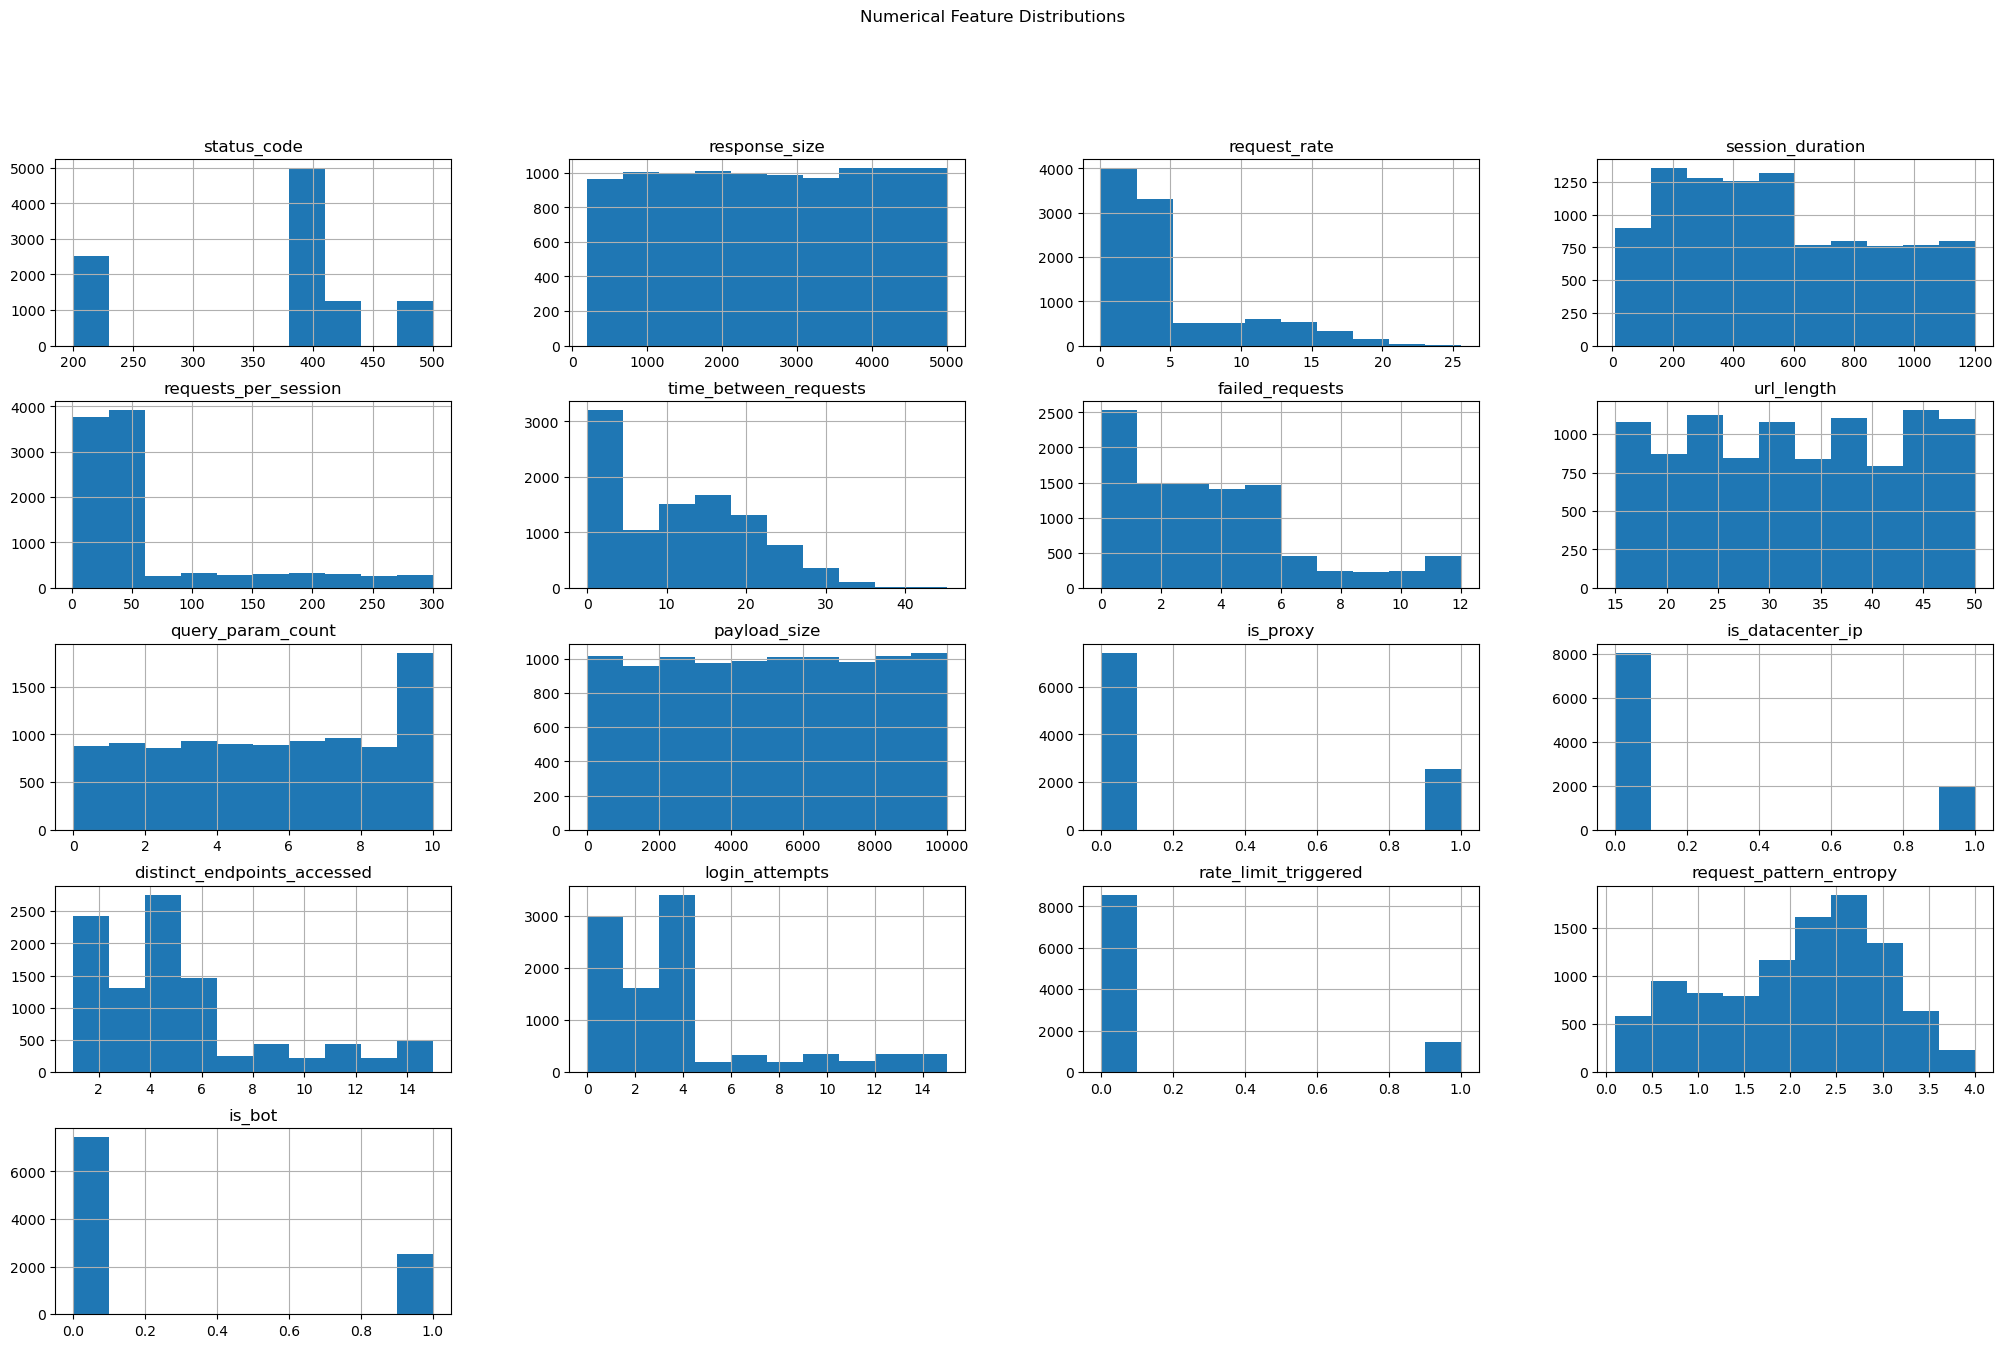

In [8]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

df[num_cols].hist(figsize=(25,15))
plt.suptitle("Numerical Feature Distributions")
plt.show()


**Data Cleaning/Data Validation**

In [9]:
for col in df.columns:
    if df[col].dtype == object:
       df[col] = df[col].str.lower()

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

ip_address
['7.190.71.63' '2.195.207.41' '159.227.221.93' ... '163.205.76.253'
 '68.11.90.34' '159.130.37.106']

timestamp
['2025-01-11 20:03:33' '2025-01-21 12:22:53' '2025-01-29 00:39:50' ...
 '2025-01-23 10:52:56' '2025-01-13 03:35:06' '2025-01-03 16:51:05']

http_method
['post' 'put' 'get' 'delete' 'patch']

endpoint
['/api/cart' '/api/products' '/api/search' '/api/orders'
 '/api/user/profile' '/api/login' '/api/payment']

status_code
[401 500 400 429 404 200 403 201]

response_size
[4664 4592 3232 ... 3494  601 3642]

user_agent
['mozilla/5.0 (windows nt 10.0; win64; x64) applewebkit/537.36 (khtml, like gecko) chrome/119.0.0.0 safari/537.36'
 'mozilla/5.0 (macintosh; intel mac os x 10_15_7) applewebkit/605.1.15 (khtml, like gecko) version/17.0 safari/605.1.15'
 'mozilla/5.0 (iphone; cpu iphone os 17_1 like mac os x) applewebkit/605.1.15 (khtml, like gecko) version/17.1 mobile/15e148 safari/604.1'
 'mozilla/5.0 (compatible; semrushbot/7~bl; +http://www.semrush.com/bot.html)'
 'mozi

In [11]:
df[df.duplicated()]

,ip_address,timestamp,http_method,endpoint,status_code,response_size,user_agent,device_type,browser,operating_system,...,url_length,query_param_count,payload_size,is_proxy,is_datacenter_ip,distinct_endpoints_accessed,login_attempts,rate_limit_triggered,request_pattern_entropy,is_bot


In [12]:
df.head()

,ip_address,timestamp,http_method,endpoint,status_code,response_size,user_agent,device_type,browser,operating_system,...,url_length,query_param_count,payload_size,is_proxy,is_datacenter_ip,distinct_endpoints_accessed,login_attempts,rate_limit_triggered,request_pattern_entropy,is_bot
0,7.190.71.63,2025-01-11 20:03:33,post,/api/cart,401,4664,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,desktop,opera,ios,...,41,3,7359,0,0,5,1,0,2.89,0
1,2.195.207.41,2025-01-21 12:22:53,put,/api/products,500,4592,mozilla/5.0 (macintosh; intel mac os x 10_15_7...,mobile,safari,windows,...,22,6,1291,0,0,1,2,0,2.36,0
2,159.227.221.93,2025-01-29 00:39:50,post,/api/cart,400,3232,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,desktop,firefox,linux,...,37,3,4374,0,0,3,0,0,2.22,0
3,19.156.163.44,2025-01-26 22:19:05,post,/api/search,429,2393,mozilla/5.0 (iphone; cpu iphone os 17_1 like m...,server,safari,android,...,19,3,9292,0,1,3,0,0,2.22,0
4,168.128.102.227,2025-01-23 06:36:04,post,/api/products,400,4374,mozilla/5.0 (macintosh; intel mac os x 10_15_7...,mobile,opera,android,...,46,1,771,0,0,2,3,0,1.47,0


In [13]:
for col in df.columns:
    if df[col].dtype == object:
        print(df[col].value_counts())
    else:
        print(col)
        print(round(df[col].describe(),2))
    print()    

ip_address
233.169.51.63      1
107.205.181.150    1
152.80.105.220     1
153.168.129.131    1
218.123.37.142     1
                  ..
168.128.102.227    1
19.156.163.44      1
159.227.221.93     1
2.195.207.41       1
7.190.71.63        1
Name: count, Length: 10000, dtype: int64

timestamp
2025-01-25 22:55:07    2
2025-01-02 12:21:03    2
2025-01-01 18:01:08    2
2025-01-30 12:08:02    2
2025-01-28 15:57:31    2
                      ..
2025-01-05 02:12:30    1
2025-01-07 01:19:59    1
2025-01-22 02:28:35    1
2025-01-06 16:41:33    1
2025-01-03 19:29:15    1
Name: count, Length: 9979, dtype: int64

http_method
get       2055
post      2016
patch     2005
delete    1985
put       1939
Name: count, dtype: int64

endpoint
/api/payment         1503
/api/products        1445
/api/user/profile    1443
/api/login           1420
/api/cart            1414
/api/search          1414
/api/orders          1361
Name: count, dtype: int64

status_code
count    10000.00
mean       366.95
std       

**EDA**

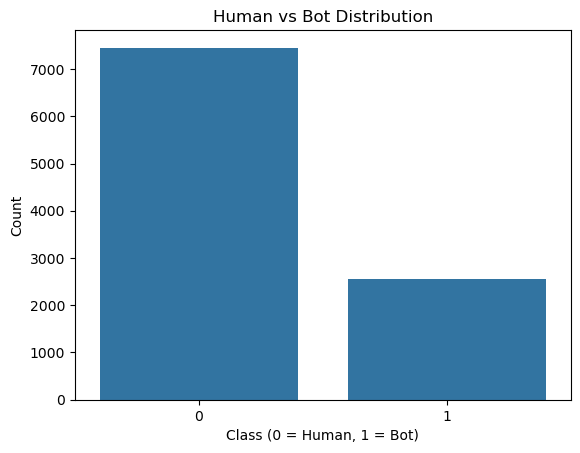

In [14]:
sns.countplot(x='is_bot', data=df)
plt.title("Human vs Bot Distribution")
plt.xlabel("Class (0 = Human, 1 = Bot)")
plt.ylabel("Count")
plt.show()



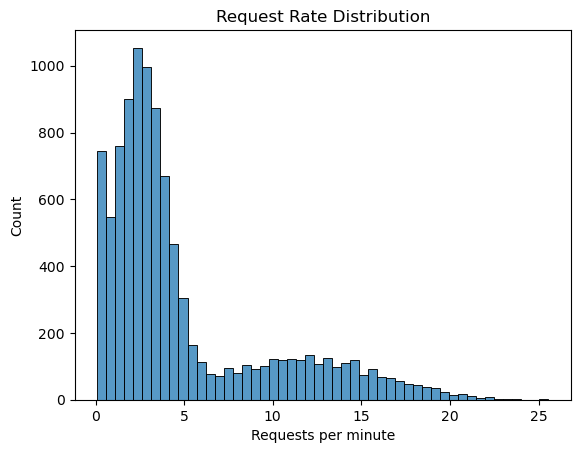

In [15]:
sns.histplot(df["request_rate"], bins=50)
plt.title("Request Rate Distribution")
plt.xlabel("Requests per minute")
plt.show()


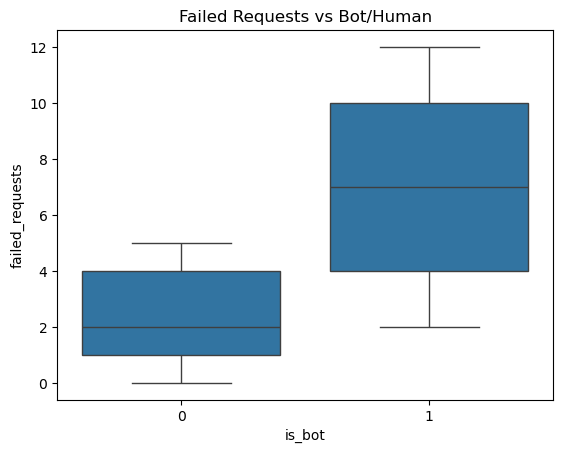

In [16]:
sns.boxplot(x="is_bot", y="failed_requests", data=df)
plt.title("Failed Requests vs Bot/Human")
plt.show()


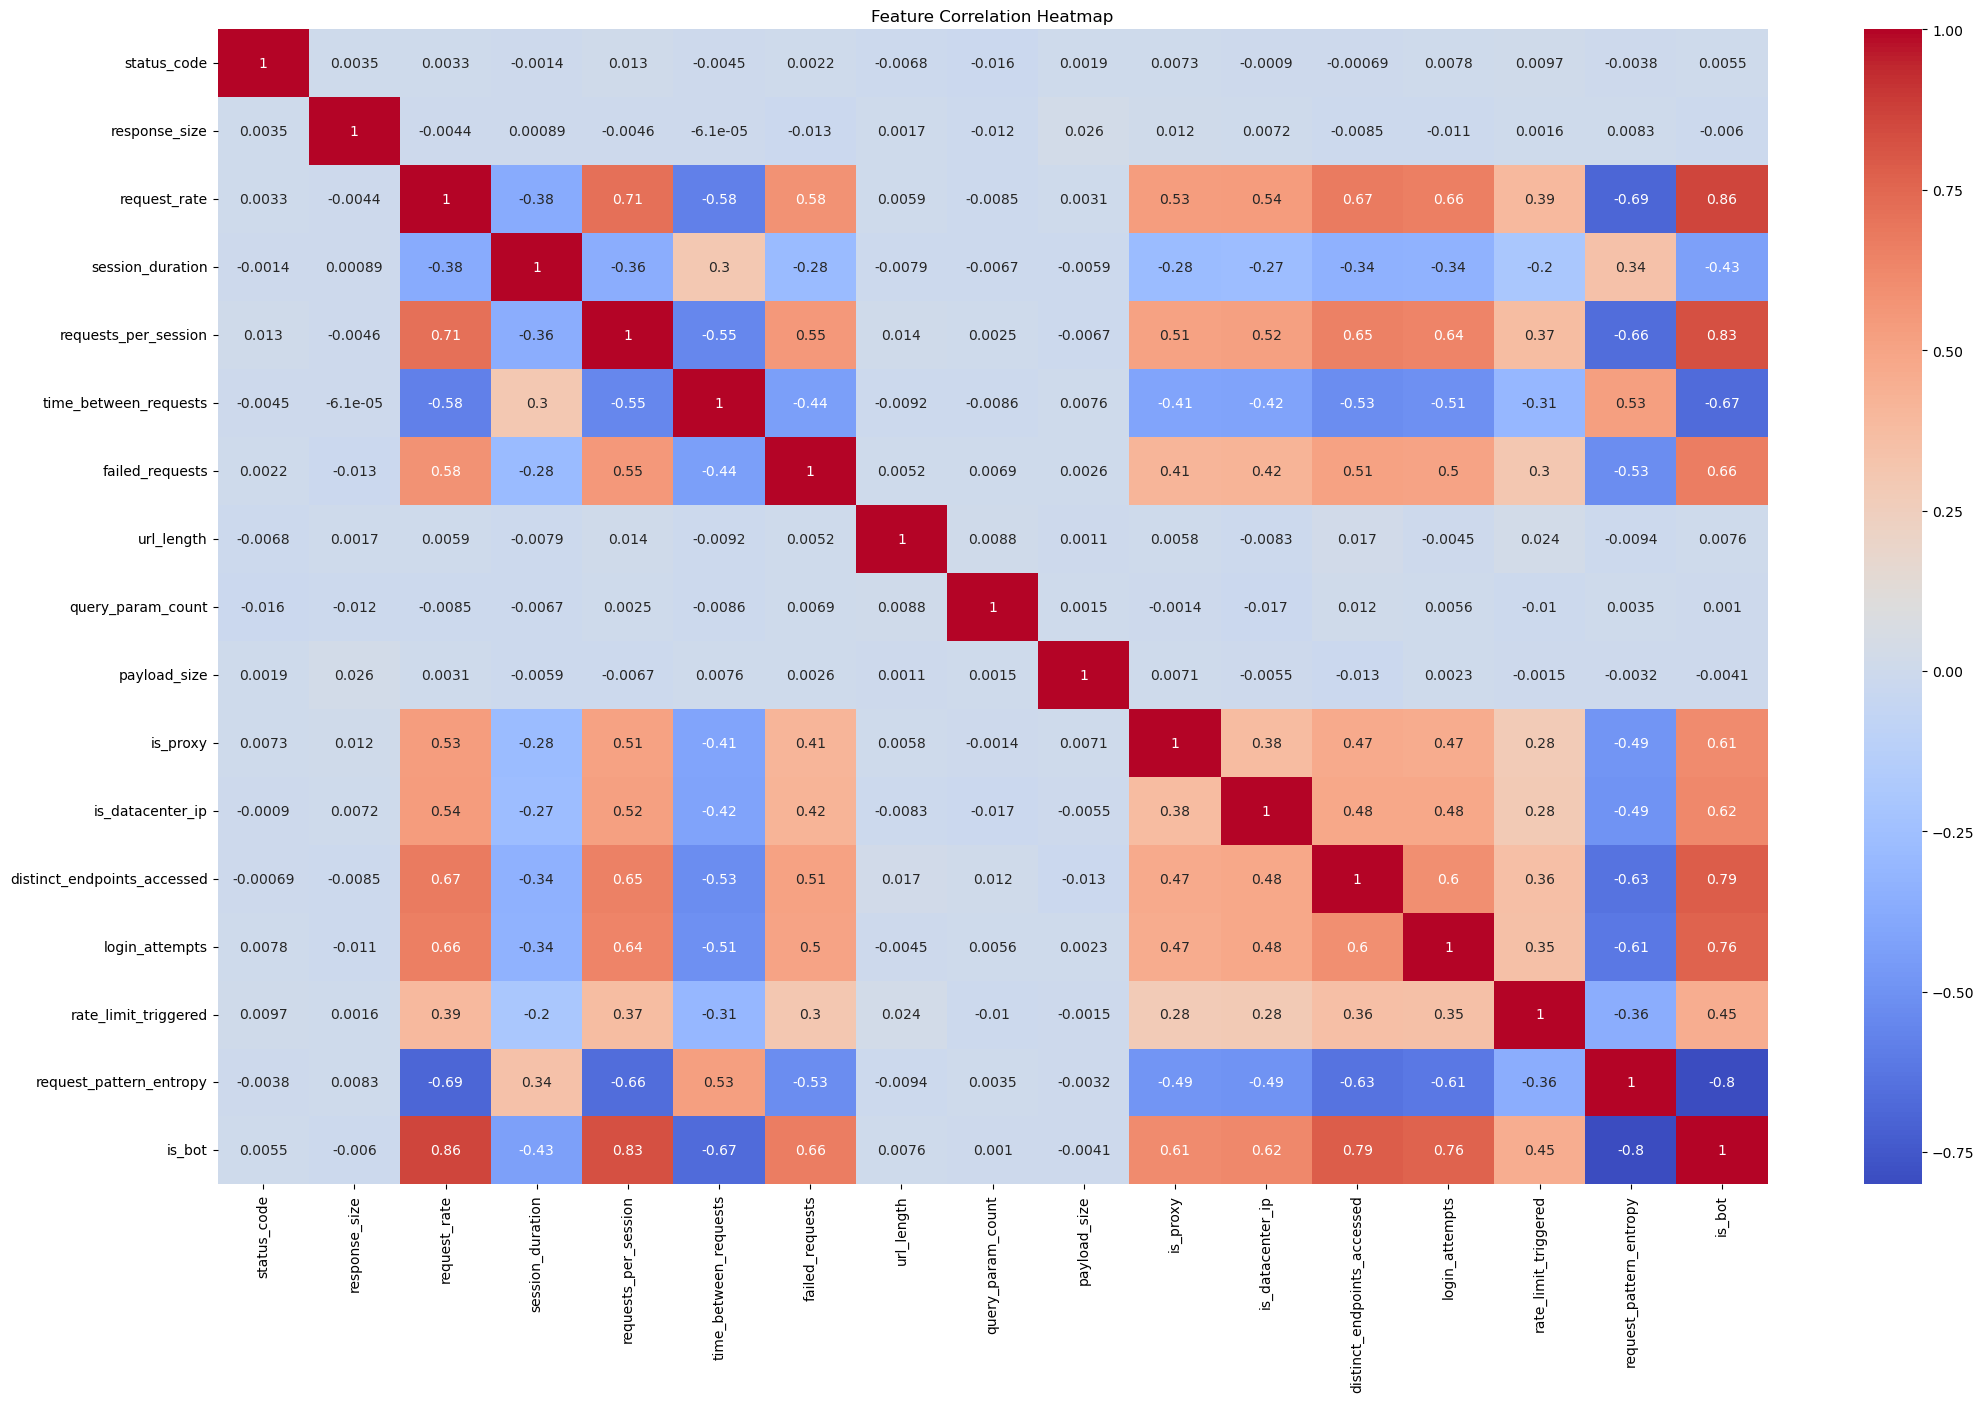

In [17]:
plt.figure(figsize=(25,15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


<Axes: xlabel='http_method', ylabel='count'>

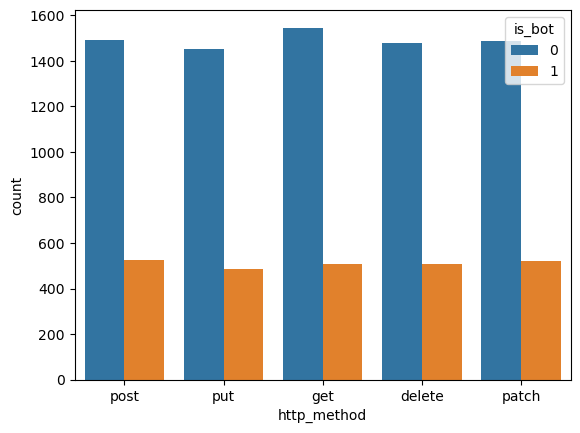

In [18]:
sns.countplot(x="http_method", hue="is_bot", data=df)


<Axes: xlabel='request_rate', ylabel='session_duration'>

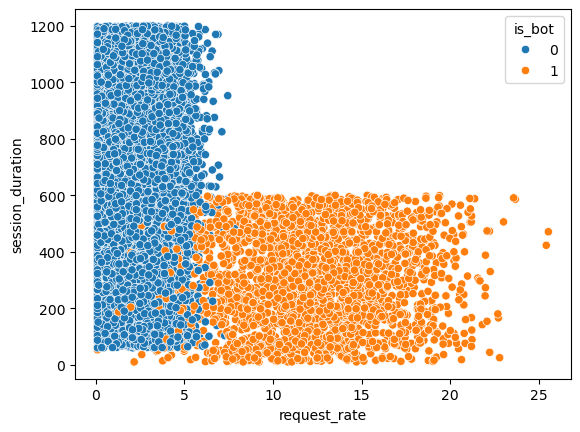

In [19]:
sns.scatterplot(x="request_rate", y="session_duration", hue="is_bot", data=df)


<Axes: xlabel='endpoint', ylabel='count'>

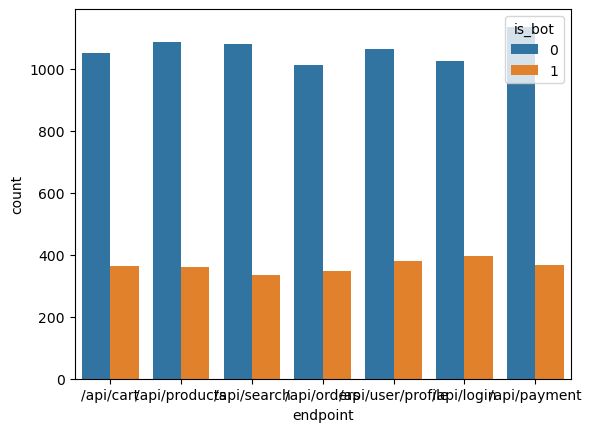

In [20]:
sns.countplot(x="endpoint", hue="is_bot", data=df)


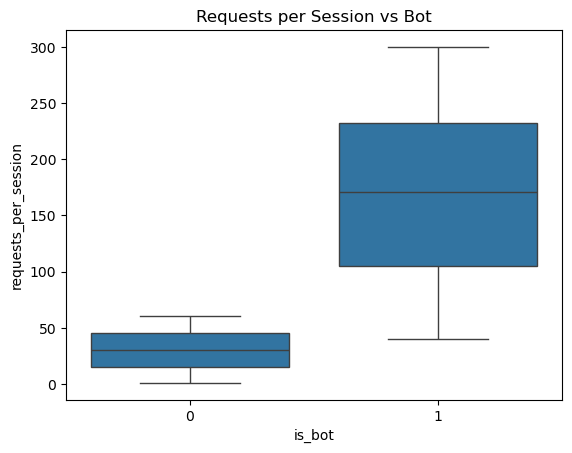

In [21]:
sns.boxplot(x='is_bot', y='requests_per_session', data=df)
plt.title("Requests per Session vs Bot")
plt.show()


**Check NA/Null values**

In [22]:
df.isna().sum()

ip_address                     0
timestamp                      0
http_method                    0
endpoint                       0
status_code                    0
response_size                  0
user_agent                     0
device_type                    0
browser                        0
operating_system               0
request_rate                   0
session_duration               0
requests_per_session           0
time_between_requests          0
failed_requests                0
url_length                     0
query_param_count              0
payload_size                   0
is_proxy                       0
is_datacenter_ip               0
distinct_endpoints_accessed    0
login_attempts                 0
rate_limit_triggered           0
request_pattern_entropy        0
is_bot                         0
dtype: int64

In [23]:
df.isnull().sum()

ip_address                     0
timestamp                      0
http_method                    0
endpoint                       0
status_code                    0
response_size                  0
user_agent                     0
device_type                    0
browser                        0
operating_system               0
request_rate                   0
session_duration               0
requests_per_session           0
time_between_requests          0
failed_requests                0
url_length                     0
query_param_count              0
payload_size                   0
is_proxy                       0
is_datacenter_ip               0
distinct_endpoints_accessed    0
login_attempts                 0
rate_limit_triggered           0
request_pattern_entropy        0
is_bot                         0
dtype: int64

**Features Selection & Dropping**

In [24]:
X = df.drop('is_bot', axis=1)
y = df["is_bot"]

In [25]:
X.head()

,ip_address,timestamp,http_method,endpoint,status_code,response_size,user_agent,device_type,browser,operating_system,...,failed_requests,url_length,query_param_count,payload_size,is_proxy,is_datacenter_ip,distinct_endpoints_accessed,login_attempts,rate_limit_triggered,request_pattern_entropy
0,7.190.71.63,2025-01-11 20:03:33,post,/api/cart,401,4664,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,desktop,opera,ios,...,0,41,3,7359,0,0,5,1,0,2.89
1,2.195.207.41,2025-01-21 12:22:53,put,/api/products,500,4592,mozilla/5.0 (macintosh; intel mac os x 10_15_7...,mobile,safari,windows,...,0,22,6,1291,0,0,1,2,0,2.36
2,159.227.221.93,2025-01-29 00:39:50,post,/api/cart,400,3232,mozilla/5.0 (windows nt 10.0; win64; x64) appl...,desktop,firefox,linux,...,1,37,3,4374,0,0,3,0,0,2.22
3,19.156.163.44,2025-01-26 22:19:05,post,/api/search,429,2393,mozilla/5.0 (iphone; cpu iphone os 17_1 like m...,server,safari,android,...,2,19,3,9292,0,1,3,0,0,2.22
4,168.128.102.227,2025-01-23 06:36:04,post,/api/products,400,4374,mozilla/5.0 (macintosh; intel mac os x 10_15_7...,mobile,opera,android,...,4,46,1,771,0,0,2,3,0,1.47


In [26]:
X = X.drop(["ip_address","timestamp","user_agent","browser","device_type","operating_system","is_datacenter_ip","rate_limit_triggered","is_proxy"],axis=1)

In [27]:
X.head()

,http_method,endpoint,status_code,response_size,request_rate,session_duration,requests_per_session,time_between_requests,failed_requests,url_length,query_param_count,payload_size,distinct_endpoints_accessed,login_attempts,request_pattern_entropy
0,post,/api/cart,401,4664,3.25,125,2,13.89,0,41,3,7359,5,1,2.89
1,put,/api/products,500,4592,4.78,249,25,13.13,0,22,6,1291,1,2,2.36
2,post,/api/cart,400,3232,4.87,223,55,21.14,1,37,3,4374,3,0,2.22
3,post,/api/search,429,2393,3.31,509,44,11.29,2,19,3,9292,3,0,2.22
4,post,/api/products,400,4374,2.86,598,48,0.01,4,46,1,771,2,3,1.47


In [28]:
X.to_csv("API Bot Detection.csv", index=False)

**Feature Engineering**

In [29]:
X.dtypes == "O"

http_method                     True
endpoint                        True
status_code                    False
response_size                  False
request_rate                   False
session_duration               False
requests_per_session           False
time_between_requests          False
failed_requests                False
url_length                     False
query_param_count              False
payload_size                   False
distinct_endpoints_accessed    False
login_attempts                 False
request_pattern_entropy        False
dtype: bool

In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
ohe = OneHotEncoder(handle_unknown='ignore')

In [32]:
ohedata = ohe.fit_transform(X[['http_method','endpoint']]).toarray()
ohe.categories_

[array(['delete', 'get', 'patch', 'post', 'put'], dtype=object),
 array(['/api/cart', '/api/login', '/api/orders', '/api/payment',
        '/api/products', '/api/search', '/api/user/profile'], dtype=object)]

In [33]:
ohedata = pd.DataFrame(ohedata, columns=ohe.get_feature_names_out())
ohedata

,http_method_delete,http_method_get,http_method_patch,http_method_post,http_method_put,endpoint_/api/cart,endpoint_/api/login,endpoint_/api/orders,endpoint_/api/payment,endpoint_/api/products,endpoint_/api/search,endpoint_/api/user/profile
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9996,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9998,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [34]:
X = pd.concat([X.drop(['http_method','endpoint'],axis=1),ohedata],axis=1)

In [35]:
X.head()

,status_code,response_size,request_rate,session_duration,requests_per_session,time_between_requests,failed_requests,url_length,query_param_count,payload_size,...,http_method_patch,http_method_post,http_method_put,endpoint_/api/cart,endpoint_/api/login,endpoint_/api/orders,endpoint_/api/payment,endpoint_/api/products,endpoint_/api/search,endpoint_/api/user/profile
0,401,4664,3.25,125,2,13.89,0,41,3,7359,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,500,4592,4.78,249,25,13.13,0,22,6,1291,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,400,3232,4.87,223,55,21.14,1,37,3,4374,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,429,2393,3.31,509,44,11.29,2,19,3,9292,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,400,4374,2.86,598,48,0.01,4,46,1,771,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [36]:
X.shape

(10000, 25)

**Train Test Split**

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=123)

In [39]:
Xtrain.shape, ytrain.shape

((8000, 25), (8000,))

**Define & Train model**

In [40]:
from sklearn.ensemble import RandomForestClassifier

RFmodel = RandomForestClassifier(
    n_estimators=50,        
    max_depth=5,            
    min_samples_split=20,   
    min_samples_leaf=10,    
    max_features="sqrt",    
    bootstrap=True,
    random_state=42
)
RFmodel.fit(Xtrain, ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [41]:
y_probs = RFmodel.predict_proba(Xtest)[:, 1]
ypred = (y_probs > 0.98).astype(int)

In [42]:
ypred

array([0, 0, 0, ..., 0, 0, 0])

In [43]:
y.value_counts()

is_bot
0    7451
1    2549
Name: count, dtype: int64

**Model Evaluation & Prediction**

In [44]:
from sklearn.metrics import f1_score,precision_score,recall_score,classification_report

In [45]:
print("F1_score:", f1_score(ytest, ypred))
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))

F1_score: 0.9144050104384134
Precision: 1.0
Recall: 0.8423076923076923


In [46]:
print("\nClassification Report:\n")
print(classification_report(ytest, ypred, target_names = ["Human", "Bot"]))


Classification Report:

              precision    recall  f1-score   support

       Human       0.95      1.00      0.97      1480
         Bot       1.00      0.84      0.91       520

    accuracy                           0.96      2000
   macro avg       0.97      0.92      0.94      2000
weighted avg       0.96      0.96      0.96      2000



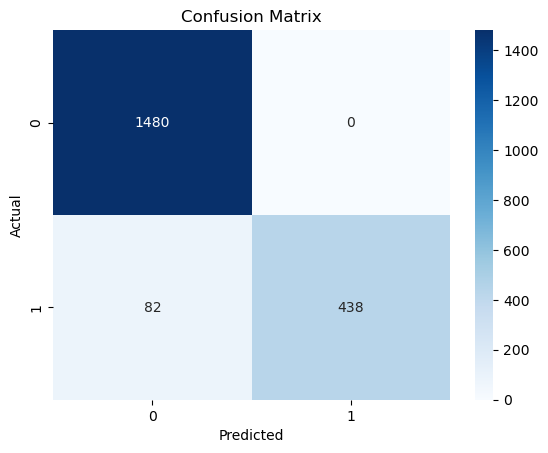

In [47]:
from sklearn.metrics import confusion_matrix
confusion_matrix(ytest, ypred)
cm = confusion_matrix(ytest, ypred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [48]:
print(Xtrain.shape)
print(Xtest.shape)


(8000, 25)
(2000, 25)


**Feature Importance**

In [49]:
importances = RFmodel.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df.head())

                        Feature  Importance
2                  request_rate    0.357678
4          requests_per_session    0.169702
12      request_pattern_entropy    0.157092
10  distinct_endpoints_accessed    0.153862
11               login_attempts    0.081674


**Save model**

In [50]:
import joblib

In [51]:
joblib.dump(RFmodel,"RFmodel.pkl")
joblib.dump(ohe,"ohe.pkl")


['ohe.pkl']